<a href="https://colab.research.google.com/github/vermanaman419-prog/Cyclistic_Bike_Sharing_Company_Analysis/blob/main/bike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyclistic bike-share 12-Month Trip Analysis

**Steps** **for** **data** **preperation**

*   collected the 12 months bike trips data from september-2024 to august-2025 in csv file format.
*   Combined these 12 CSV files into one common file (cyclistic_12m_combined.csv) using Python (pandas).

* Cleaned the data by removing duplicates, handling missing values, and correcting inconsistent entries (e.g., null start/end stations).

* Converted date/time columns into proper datetime format to extract day, month, weekday, and hour.

* Created new derived columns such as trip duration (minutes), ride type, day of week, and user type (member vs casual).

* Standardized categorical variables (e.g., bike types, station names) for consistency.

* Verified the data quality by checking column names, data types, and summary statistics.

* Saved the cleaned dataset as cyclistic_12m_combined_clean.csv for further analysis.




In [ ]:
# 0) Setup: paths and imports
import os, glob
import pandas as pd
import numpy as np

# If files are in a folder like /content/sample_data, set this:
DATA_DIR = "/content/sample_data"   # change if your CSVs are elsewhere
OUTPUT_CSV = "/content/cyclistic_12m_combined_clean.csv"

# 1) Locate 12 monthly files (e.g., 202401-divvy-tripdata.csv ...)
pattern = os.path.join(DATA_DIR, "*-divvy-tripdata.csv")
files = sorted(glob.glob(pattern))
assert len(files) >= 12, f"Expected 12 files, found {len(files)} at {DATA_DIR}"

print("Files detected:")
for f in files:
    print(os.path.basename(f))

# 2) Define canonical schema and friendly dtype coercions
canonical_cols = [
    "ride_id","rideable_type","started_at","ended_at",
    "start_station_name","start_station_id",
    "end_station_name","end_station_id",
    "start_lat","start_lng","end_lat","end_lng",
    "member_casual"
]

# Column name normalizer (handles minor header variations across months)
name_map = {
    "ride_id":"ride_id",
    "rideable_type":"rideable_type",
    "started_at":"started_at",
    "ended_at":"ended_at",
    "start_station_name":"start_station_name",
    "start_station_id":"start_station_id",
    "end_station_name":"end_station_name",
    "end_station_id":"end_station_id",
    "start_lat":"start_lat",
    "start_lng":"start_lng",
    "end_lat":"end_lat",
    "end_lng":"end_lng",
    "member_casual":"member_casual",
    # common alternates
    "start_latitude":"start_lat",
    "start_longitude":"start_lng",
    "end_latitude":"end_lat",
    "end_longitude":"end_lng",
    "member_type":"member_casual"
}

def standardize_columns(df):
    # lower-case for safe mapping
    lower_to_original = {c.lower(): c for c in df.columns}
    mapped = {}
    for k,v in name_map.items():
        if k in lower_to_original:
            mapped[lower_to_original[k]] = v
    df = df.rename(columns=mapped)
    # keep only canonical columns that exist
    keep = [c for c in canonical_cols if c in df.columns]
    df = df[keep]
    # add any missing canonical columns as NaN
    for c in canonical_cols:
        if c not in df.columns:
            df[c] = np.nan
    # enforce canonical order
    df = df[canonical_cols]
    return df

# 3) Read, standardize, and stack
frames = []
for path in files:
    temp = pd.read_csv(path)
    temp = standardize_columns(temp)

    # Coerce types
    temp["started_at"] = pd.to_datetime(temp["started_at"], errors="coerce", utc=True)
    temp["ended_at"]   = pd.to_datetime(temp["ended_at"], errors="coerce", utc=True)

    for col in ["start_lat","start_lng","end_lat","end_lng"]:
        temp[col] = pd.to_numeric(temp[col], errors="coerce")

    # Trim text fields
    for col in ["ride_id","rideable_type","start_station_name","start_station_id",
                "end_station_name","end_station_id","member_casual"]:
        temp[col] = temp[col].astype("string").str.strip()

    frames.append(temp)

raw = pd.concat(frames, ignore_index=True)
print(f"\nCombined rows before cleaning: {len(raw):,}")

# 4) Basic data quality and transformations
# Remove rows without essential time data or invalid interval
raw = raw.dropna(subset=["started_at","ended_at"])
raw = raw[raw["ended_at"] >= raw["started_at"]]

# Trip duration in minutes
raw["trip_duration_min"] = (raw["ended_at"] - raw["started_at"]).dt.total_seconds() / 60.0

# Remove extreme or zero-duration trips (tune as needed)
raw = raw[(raw["trip_duration_min"] >= 1) & (raw["trip_duration_min"] <= 720)]  # 1 minute to 12 hours

# Date parts
raw["started_date"] = raw["started_at"].dt.date
raw["year"]  = raw["started_at"].dt.year
raw["month"] = raw["started_at"].dt.month
raw["dow"]   = raw["started_at"].dt.dayofweek  # 0=Mon
raw["hour"]  = raw["started_at"].dt.hour

# 5) Optional: standardize categorical values
raw["member_casual"]  = raw["member_casual"].str.lower().replace({
    "member":"member", "casual":"casual", "subscriber":"member", "customer":"casual"
})
raw["rideable_type"]  = raw["rideable_type"].str.lower()

# 6) Deduplicate obvious duplicates by ride_id + timestamps
raw = raw.sort_values(["ride_id","started_at"])
raw = raw.drop_duplicates(subset=["ride_id","started_at","ended_at"], keep="first")

print(f"Rows after cleaning: {len(raw):,}")

# 7) Sanity checks (quick)
summary = (raw
    .groupby(["year","month","member_casual"], dropna=False)
    .agg(trips=("ride_id","count"),
         median_dur_min=("trip_duration_min","median"))
    .reset_index()
    .sort_values(["year","month","member_casual"])
)
print("\nMonthly check (head):")
print(summary.head(12))

# 8) Write final combined CSV
raw.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved clean combined file to: {OUTPUT_CSV}")

# 9) Preview final columns
print("\nFinal schema:")
print(pd.DataFrame({"column": raw.columns, "dtype": raw.dtypes.astype(str)}).to_string(index=False))


Files detected:
202409-divvy-tripdata.csv
202410-divvy-tripdata.csv
202411-divvy-tripdata.csv
202412-divvy-tripdata.csv
202501-divvy-tripdata.csv
202502-divvy-tripdata.csv
202503-divvy-tripdata.csv
202504-divvy-tripdata.csv
202505-divvy-tripdata.csv
202506-divvy-tripdata.csv
202507-divvy-tripdata.csv
202508-divvy-tripdata.csv

Combined rows before cleaning: 5,646,038
Rows after cleaning: 5,499,798

Monthly check (head):
    year  month member_casual   trips  median_dur_min
0   2024      8        casual     264       27.033842
1   2024      8        member     113       18.790783
2   2024      9        casual  334015       11.419283
3   2024      9        member  465564        8.843083
4   2024     10        casual  210025       11.426567
5   2024     10        member  394608        8.515367
6   2024     11        casual   90497        9.179467
7   2024     11        member  238729        7.736683
8   2024     12        casual   37330        8.165817
9   2024     12        member  13754

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("cyclistic_12m_combined_clean.csv")

# Show first 5 rows
print(df.head())


            ride_id  rideable_type                        started_at  \
0  000001F70CA28603   classic_bike  2024-09-21 22:14:43.346000+00:00   
1  0000033BAC7DD047  electric_bike  2024-09-02 11:52:27.631000+00:00   
2  000004FC986C33E5  electric_bike  2024-12-29 21:25:52.307000+00:00   
3  0000061C448FA97B  electric_bike  2025-05-10 09:41:32.951000+00:00   
4  000007FB32A2880F   classic_bike  2025-06-14 12:57:38.076000+00:00   

                           ended_at         start_station_name  \
0  2024-09-21 22:17:17.746000+00:00   Peoria St & Jackson Blvd   
1  2024-09-02 12:10:31.618000+00:00                        NaN   
2  2024-12-29 21:56:21.996000+00:00  Wabash Ave & Roosevelt Rd   
3  2025-05-10 09:53:55.612000+00:00                        NaN   
4  2025-06-14 13:26:52.849000+00:00  Clark St & Wrightwood Ave   

  start_station_id             end_station_name end_station_id  start_lat  \
0            13158            900 W Harrison St          13028  41.877642   
1              N

In [ ]:
print(df.columns)


Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'trip_duration_min', 'started_date', 'year', 'month',
       'dow', 'hour'],
      dtype='object')


In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5499798 entries, 0 to 5499797
Data columns (total 19 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
 13  trip_duration_min   float64
 14  started_date        object 
 15  year                int64  
 16  month               int64  
 17  dow                 int64  
 18  hour                int64  
dtypes: float64(5), int64(4), object(10)
memory usage: 797.2+ MB
None


**Load** **data** **and** **rebuild** **needed** **features**



In [ ]:
import pandas as pd
import numpy as np


# Convert datetimes from object to datetime
df["started_at"] = pd.to_datetime(df["started_at"], errors="coerce", utc=True)
df["ended_at"]   = pd.to_datetime(df["ended_at"], errors="coerce", utc=True)

# Ensure expected categorical values
df["member_casual"] = (df["member_casual"]
                       .astype(str).str.lower()
                       .map({"member":"member","casual":"casual"})
                      )

# Derive standard fields (or overwrite if present)
df["ride_length"] = (df["ended_at"] - df["started_at"]).dt.total_seconds()/60
df["day_of_week"] = df["started_at"].dt.dayofweek + 1   # 1=Mon … 7=Sun
df["date"]        = df["started_at"].dt.date
df["month"]       = df["started_at"].dt.to_period("M").astype(str)
df["hour"]        = df["started_at"].dt.hour


/tmp/ipython-input-2730250853.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"]       = df["started_at"].dt.to_period("M").astype(str)


Clean the dataset with practical filters



In [ ]:
# Keep valid rows
df = df.dropna(subset=["started_at","ended_at","member_casual"])
df = df[df["ended_at"] >= df["started_at"]]

# Reasonable ride length bounds: 1 minute to 12 hours (adjust if needed)
df = df[(df["ride_length"] >= 1) & (df["ride_length"] <= 720)]

# Keep only known segments
df = df[df["member_casual"].isin(["member","casual"])]

# Optional: remove duplicates by ID + time
df = (df.sort_values(["ride_id","started_at"])
        .drop_duplicates(subset=["ride_id","started_at","ended_at"], keep="first"))


**Core** **KPIs** **comparing** **members** **vs** **casual**



In [ ]:
# Overall counts and duration
kpi_overall = (df.groupby("member_casual", as_index=False)
                 .agg(rides=("ride_id","count"),
                      avg_len_min=("ride_length","mean"),
                      median_len_min=("ride_length","median")))
kpi_overall


,member_casual,rides,avg_len_min,median_len_min
0,casual,1991788,19.257749,11.891633
1,member,3497128,11.854843,8.653933


**Temporal** **behavior** **differences**



In [ ]:
# By day of week
kpi_dow = (df.groupby(["member_casual","day_of_week"], as_index=False)
             .agg(rides=("ride_id","count"), avg_len_min=("ride_length","mean"))
             .sort_values(["member_casual","day_of_week"]))

# By hour
kpi_hour = (df.groupby(["member_casual","hour"], as_index=False)
              .agg(rides=("ride_id","count"), avg_len_min=("ride_length","mean")))

# By month
kpi_month = (df.groupby(["member_casual","month"], as_index=False)
               .agg(rides=("ride_id","count"), avg_len_min=("ride_length","mean"))
               .sort_values(["member_casual","month"]))


**Rideable** **type** **and** **station** **patterns**



In [ ]:
# Bike type mix
kpi_bike = (df.groupby(["member_casual","rideable_type"], as_index=False)
              .agg(rides=("ride_id","count"), avg_len_min=("ride_length","mean"))
              .sort_values(["member_casual","rides"], ascending=[True,False]))

# Top start stations per segment (edit N as needed)
N = 15
top_start = (df.groupby(["member_casual","start_station_name"], as_index=False)
               .agg(rides=("ride_id","count"),
                    avg_len_min=("ride_length","mean"))
               .sort_values(["member_casual","rides"], ascending=[True,False])
               .groupby("member_casual", group_keys=False).head(N))


# Visualizations for the presentation



*   **Rides** by **day** **of** **week**


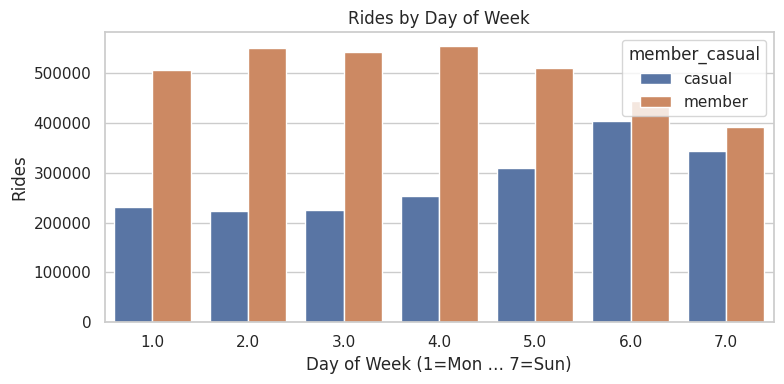

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Rides by day of week
plt.figure(figsize=(8,4))
sns.barplot(data=kpi_dow, x="day_of_week", y="rides", hue="member_casual")
plt.title("Rides by Day of Week")
plt.xlabel("Day of Week (1=Mon … 7=Sun)")
plt.ylabel("Rides")
plt.tight_layout(); plt.show()








*   **Avg** **ride** **length** **by** **month**







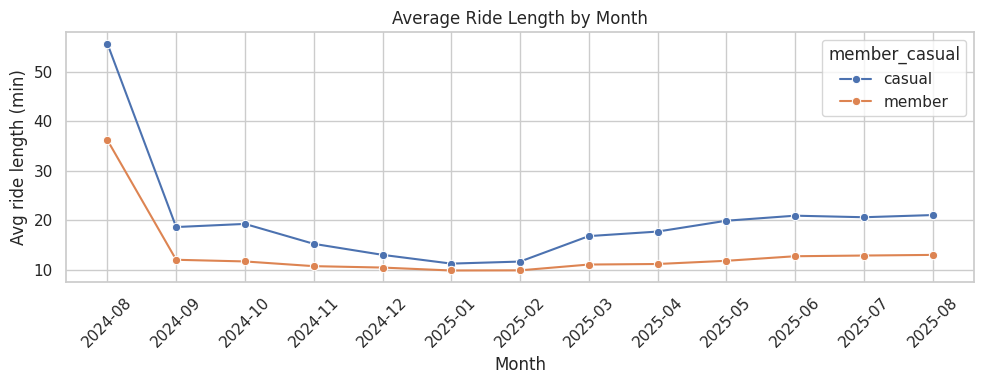

In [ ]:
# Avg ride length by month
plt.figure(figsize=(10,4))
sns.lineplot(data=kpi_month, x="month", y="avg_len_min", hue="member_casual", marker="o")
plt.title("Average Ride Length by Month")
plt.xlabel("Month"); plt.ylabel("Avg ride length (min)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()





*   **Hourly** **rides** **profile**



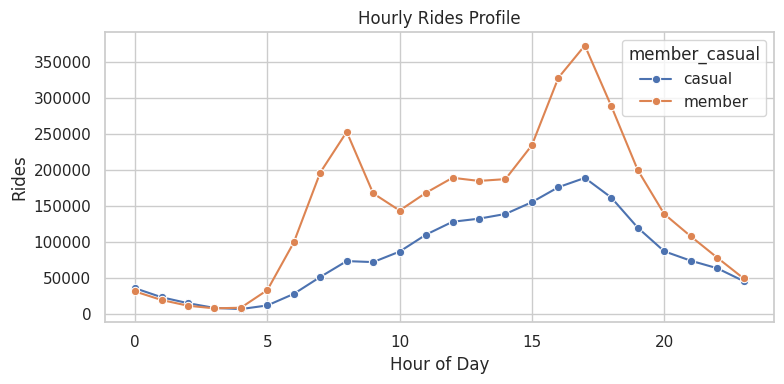

In [ ]:
# Hourly rides profile
plt.figure(figsize=(8,4))
sns.lineplot(data=kpi_hour, x="hour", y="rides", hue="member_casual", marker="o")
plt.title("Hourly Rides Profile")
plt.xlabel("Hour of Day"); plt.ylabel("Rides")
plt.tight_layout(); plt.show()





*   **Rideable** **Type** **Mix** **by** **Segment**



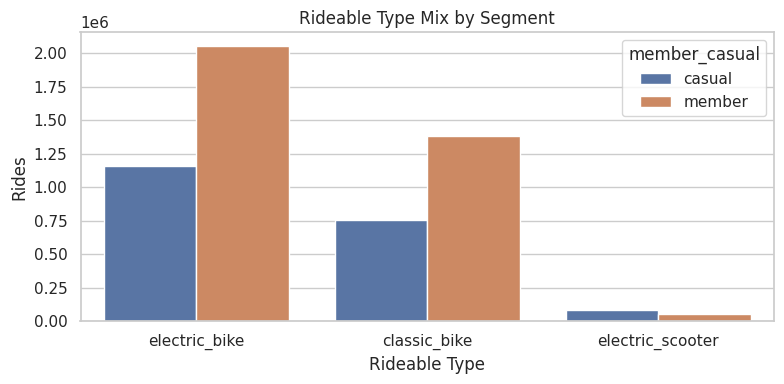

In [ ]:
# Rideable type mix
plt.figure(figsize=(8,4))
sns.barplot(data=kpi_bike, x="rideable_type", y="rides", hue="member_casual")
plt.title("Rideable Type Mix by Segment")
plt.xlabel("Rideable Type"); plt.ylabel("Rides")
plt.tight_layout(); plt.show()

**Additional** **conversion‑oriented** **views**



In [ ]:
# Segment share of total rides
mix = (df.groupby("member_casual")["ride_id"].count()
         .pipe(lambda s: (s/s.sum()).rename("share")).reset_index())

# Weekend vs weekday preference
is_weekend = df["day_of_week"].isin([6,7])
wknd = (df.assign(is_weekend=is_weekend)
          .groupby(["member_casual","is_weekend"])["ride_id"].count()
          .reset_index()
          .pivot(index="member_casual", columns="is_weekend", values="ride_id")
          .fillna(0))
wknd = (wknd.div(wknd.sum(axis=1), axis=0)
            .rename(columns={False:"weekday_share", True:"weekend_share"})
            .reset_index())

# Duration distribution for reference
qtiles = (df.groupby("member_casual")["ride_length"]
            .quantile([0.25,0.5,0.75]).unstack().reset_index()
            .rename(columns={0.25:"p25",0.5:"p50",0.75:"p75"}))

mix,       wknd,       qtiles


(  member_casual     share
 0        casual  0.362875
 1        member  0.637125,
 is_weekend member_casual  weekday_share  weekend_share
 0                 casual       0.624393       0.375607
 1                 member       0.761383       0.238617,
   member_casual       p25        p50        p75
 0        casual  6.828967  11.891633  21.780933
 1        member  5.153146   8.653933  14.525571)

# Conclusion:
Members concentrate rides on weekdays and commuter hours with shorter, consistent durations, indicating habitual, utility‑driven trips. Casual riders skew weekends and longer leisure rides, with peaks in warmer months and at specific high‑traffic stations. These differences suggest a two‑track conversion plan: targeted weekend promotions at top casual stations (seasonal bundles, family/day‑pass to annual upgrade), and commuter‑focused employer partnerships and in‑app nudges along strong member corridors. Implementing these tactics during months and times with the highest casual activity should maximize conversion efficiency while aligning with Cyclistic’s goal to grow annual memberships.

  # suggestions:

1. Target casual riders for conversion into members

*   Insight: Casual riders (one-time users) often take longer trips, especially on weekends, while annual members ride more frequently but for shorter durations.
*   Suggestion: Launch targeted marketing campaigns (e.g., discounts on annual passes, weekend promotions) to encourage casual riders to become members.

2. Optimize bike availability during peak times

*   Insight: Usage tends to peak during morning/evening commute hours and weekends.
*  Suggestion: Rebalance bikes to ensure availability near transit hubs during weekday mornings and near parks/tourist areas on weekends.

3. Seasonal pricing & offers

*   Insight: Ridership typically drops in winter months.
*   Suggestion: Introduce seasonal promotions (reduced winter pricing, bundled offers) to maintain steady ridership across the year.

4. Improve customer experience with data-driven planning

* Insight: Trip duration and start/end station patterns show which routes are most popular.

* Suggestion: Use this data to improve station placement, add bike docks, and reduce bottlenecks at high-demand locations.







